In [ ]:
import numpy as np
import matplotlib.pyplot as plt

## Particle Decay
A radioactive source emits $N$ unstable particles. The particles are emitted at constant speed along the $x$ axis. For each particle, indexed by  $i\in\{1,\dots,N\}$, we mark the  position $x_i$ where it decays. 

We know that the probability density of decaying at $x$ is 
\begin{equation}
P(x|\lambda)=\frac{1}{\lambda}e^{-x/\lambda},
\end{equation}

for an unknown parameter $\lambda$.

Given $\mathbf x=(x_1,\dots,x_N)$ our objective is to estimate $\lambda$

In [ ]:
lambda_star=1 #true value of the parameter we use to generate the data. Also said "ground truth"
N=1000

In [ ]:
np.random.seed(123)
x=np.random.exponential(scale=lambda_star,size=N) #generate data

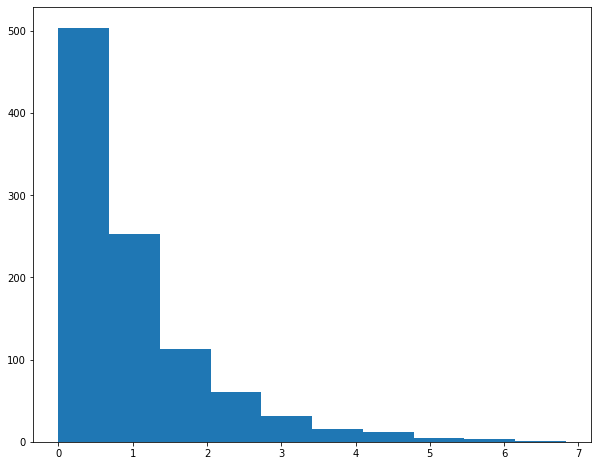

In [ ]:
#plot data
plt.figure(figsize=(10,8))
plt.hist(x);
#plt.yscale('log')

#### Log likelihood computation
$\ell(\lambda)=\log P(\mathbf x|\lambda)=\sum_{i=1}^N \log P(x_i|\lambda)=-N\log\lambda-\frac{1}{\lambda}\sum_{i=1}^N x_i $


In [ ]:
def log_likelihood_exp(lambd,x): #log likelihood of the exponential distribution
    l=-np.sum(np.log(lambd)+x/lambd)
    return l

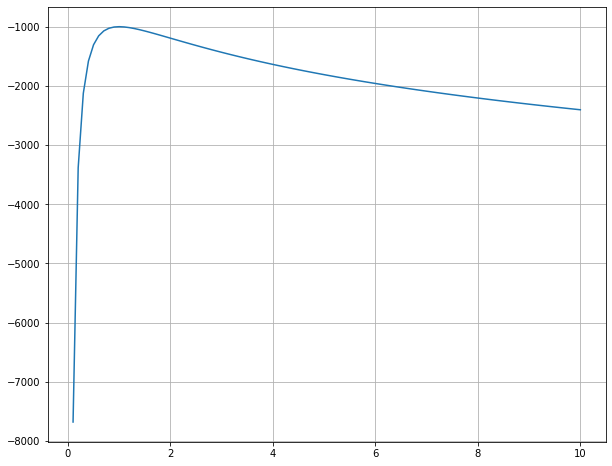

In [ ]:
lambda_range=np.linspace(1e-1,10,100)
log_likelihood_values=[log_likelihood_exp(lambd,x) for lambd in lambda_range]
plt.figure(figsize=(10,8))
plt.grid()
plt.plot(lambda_range,log_likelihood_values)

In [ ]:
from scipy.optimize import minimize

In [ ]:
def neg_log_likelihood_exp(lambd,x): #scipy only minimizes so we must define the log likelihood with the sign changed
    return -log_likelihood_exp(lambd,x)




In [ ]:
opt_result=minimize(neg_log_likelihood_exp,x0=1e-2,args=(x)) # minimize -log_likelohood
opt_result 

      fun: 998.3045399332606
 hess_inv: array([[0.00099696]])
      jac: array([-7.62939453e-06])
  message: 'Optimization terminated successfully.'
     nfev: 39
      nit: 7
     njev: 13
   status: 0
  success: True
        x: array([0.99830597])

Now introduce the prior distribution $P(\lambda)=\frac{1}{\lambda_0}e^{-\lambda/\lambda_0}$

In [ ]:
lambda0=0.1
def prior_lambda(lambd,lambda0):
    return np.exp(-lambd/lambda0)/lambda0

#def log_prior_lambda(lambd,lambda0):
    #return -np.log(lambda0)-lambd/lambda0

Compute the unnormalized log poterior (we want to maximize it so the normalization is not important)

In [ ]:
def log_posterior(lambd, lambda0,x):
    return log_likelihood_exp(lambd,x)+np.log(prior_lambda(lambd,lambda0))
    #return log_likelihood_exp(lambd,x)+log_prior_lambda(lambd,lambda0)

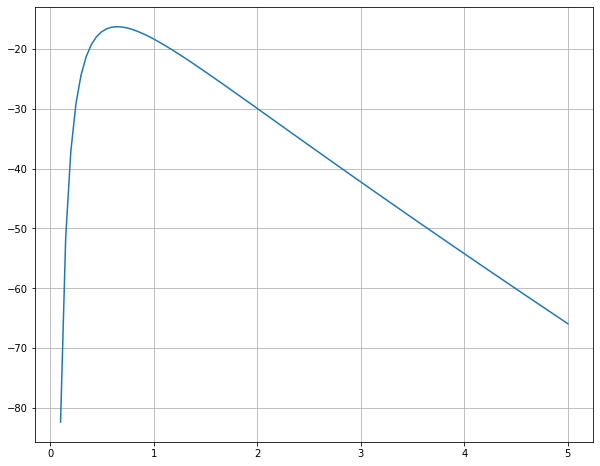

In [ ]:
lambda_range=np.linspace(1e-1,5,100)
#using a restricted number of samples
log_posterior_values=[log_posterior(lambd,lambda0,x[:10]) for lambd in lambda_range]
plt.figure(figsize=(10,8))
plt.grid()
plt.plot(lambda_range,log_posterior_values)

In [ ]:
def neg_log_posterior(lambd,lambd0,x):
    return -log_posterior(lambd,lambda0,x)

In [ ]:
opt_result=minimize(neg_log_posterior,x0=1,args=(lambda0,x),method='Powell') # minimize -log_likelohood
opt_result 

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:2: RuntimeWarning: invalid value encountered in log
  


   direc: array([[1.]])
     fun: array(16.30225712)
 message: 'Optimization terminated successfully.'
    nfev: 27
     nit: 2
  status: 0
 success: True
       x: array(0.64753745)

## Bent coin
Now repeat the previous computations in the case of the bent coin example
let $\mathbf s=(s_1,\dots,s_N)$ be a vector with i.i.d components , with $x_i\in\{0,1\} \;\; \forall i$, sampled from
\begin{equation}
P(s|p)=p^s(1-p)^{1-s}
\end{equation}


In [ ]:
p_star=0.1 #ground truth
N=1000 #number of samples
np.random.seed(12)

In [ ]:
# Generate the data s=(s_1,...,s_N) from the probability measure above with p=p_star, and print the first 10 samples s_1,...s_10

In [ ]:
#define the log_likelihood function following this prototype
def log_likelihood(p,s): #p is a scalar, while s is a 1D numpy array of arbitrary length
    pass
    

In [ ]:
#plot the log_likelihood as a function of p between 0 and 1
#careful when choosing the values of p, the log_likelihood may blow up!

Now add the prior $P(p)=6p(1-p)$

In [ ]:
def prior(p):
    return 6*p*(1-p)

In [ ]:
#The posterior distribution is P(p|s)=P(s|p)P(p)/P(s). Ignore the normalization P(p) and compute log(P(s|p)P(p))
def log_posterior(p,s):
    pass

In [ ]:
#plot the log posterior as a function of p

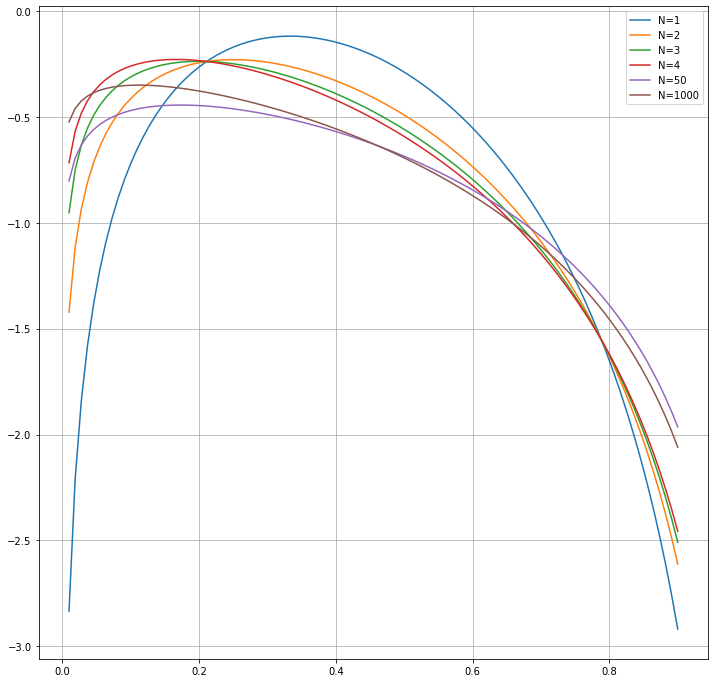

In [ ]:
# Look at how the MAP estimator approaches the ML one as N tends to infinity
p_star=0.1
p_values=np.linspace(1e-2,1-1e-1,100) 
plt.figure(figsize=(12,12))
for N in [1,2,3,4,50,1000]:
    plt.plot(p_values,log_posterior(p_values,s[:N])/N,label="N=%d"%N)
plt.legend()
plt.grid()